In [1]:
# from opticalib.ground import osutils as osu

from astropy.io import fits

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import os

In [ ]:
def computeRadialProfile(image, centerInPxY=None, centerInPxX=None):
    if centerInPxX is None:
        centerInPxX = image[1].shape//2
    if centerInPxY is None:
        centerInPxY = image[0].shape//2
    yCoord, xCoord= np.indices(image.shape)
    yCoord= (yCoord - centerInPxY)
    xCoord= (xCoord - centerInPxX)
    rCoord=np.sqrt(xCoord**2 + yCoord**2)
    indexR= np.argsort(rCoord.flat)
    radialDistancesSorted= rCoord.flat[indexR]
    imageValuesSortedByRadialDistance= image.flat[indexR]
    integerPartOfRadialDistances= radialDistancesSorted.astype(np.int64)
    deltaRadialDistance= integerPartOfRadialDistances[1:] - \
        integerPartOfRadialDistances[:-1]
    radialDistanceChanges= np.where(deltaRadialDistance)[0]
    nPxInBinZero= radialDistanceChanges[0]+ 1
    nPxInRadialBin= radialDistanceChanges[1:] - \
        radialDistanceChanges[:-1]
    imageRadialCumSum= np.cumsum(imageValuesSortedByRadialDistance,
                                 dtype=np.float64)
    imageSumInBinZero= imageRadialCumSum[radialDistanceChanges[0]]
    imageSumInRadialBin= \
        imageRadialCumSum[radialDistanceChanges[1:]] - \
        imageRadialCumSum[radialDistanceChanges[:-1]]
    profileInZero= imageSumInBinZero / nPxInBinZero
    profileFromOne= imageSumInRadialBin / nPxInRadialBin
    profile= np.hstack([profileInZero, profileFromOne])

    distanceRadialCumSum= np.cumsum(radialDistancesSorted)
    distanceSumInBinZero= distanceRadialCumSum[radialDistanceChanges[0]]
    distanceSumInRadialBin= \
        distanceRadialCumSum[radialDistanceChanges[1:]] - \
        distanceRadialCumSum[radialDistanceChanges[:-1]]
    distanceInZero= distanceSumInBinZero / nPxInBinZero
    distanceFromOne= distanceSumInRadialBin / nPxInRadialBin
    radialDistance= np.hstack([distanceInZero, distanceFromOne])
    return profile, radialDistance


def get_photocenter(image):
    ny, nx = image.shape
    x = np.arange(nx)
    y = np.arange(ny)
    X,Y = np.meshgrid(x, y)
    qy = np.sum(Y * image) / np.sum(image)
    qx = np.sum(X * image) / np.sum(image)
    return qx,qy 

def peak_xy_subpixel(im, half_window=3):
    y0, x0 = np.unravel_index(np.argmax(im), im.shape)
    y_min = max(0, y0 - half_window)
    y_max = min(im.shape[0], y0 + half_window + 1)
    x_min = max(0, x0 - half_window)
    x_max = min(im.shape[1], x0 + half_window + 1)
    patch = im[y_min:y_max, x_min:x_max]
    yy, xx = np.indices(patch.shape)
    w = patch - np.min(patch)
    if np.sum(w) <= 0:
        return float(x0), float(y0)
    x = np.sum((xx + x_min) * w) / np.sum(w)
    y = np.sum((yy + y_min) * w) / np.sum(w)
    return float(x), float(y)


def best_circle_fit(image,show_fit:bool=False, thr:float=0.5):
    """Estimate the center coordinates and radius of a circular bright
    feature in *image*.

    Parameters
    ----------
    image : 2-D ndarray
        Input intensity map.  The algorithm finds pixels above a threshold
        (default 50%% of the maximum value) and fits a circle to their
        locations using a simple algebraic least-squares method.
    show_fit : bool
        If ``True`` generate a figure showing the input image with the
        fitted circle overlaid as a dashed blue line and the estimated
        center marked with a cross.

    Returns
    -------
    cx, cy : float
        Estimated center coordinates (x along columns, y along rows).
    radius : float
        Radius of the fitted circle in pixel units.  If the fit fails, a
        radius of ``np.nan`` is returned.
    """
    arr = np.asarray(image, dtype=np.float64)
    maxv = arr.max()
    thresh = thr * maxv
    ys, xs = np.nonzero(arr >= thresh)
    if len(xs) < 3:
        cx, cy = get_photocenter(arr)
        if show_fit:
            plt.figure()
            plt.imshow(arr, origin='lower', cmap='gray')
            plt.plot(cy, cx, '+', c='C0')
        return cx, cy, 0.0

    x = xs.astype(np.float64)
    y = ys.astype(np.float64)
    A = np.column_stack([2 * x, 2 * y, np.ones_like(x)])
    b = x * x + y * y
    c, *_ = np.linalg.lstsq(A, b, rcond=None)
    cx, cy, c0 = c
    radius = np.sqrt(cx * cx + cy * cy + c0)

    if show_fit:
        plt.figure()
        plt.imshow(arr, origin='lower', cmap='gray')
        theta = np.linspace(0, 2*np.pi, 200)
        circle_x = cx + radius * np.cos(theta)
        circle_y = cy + radius * np.sin(theta)
        plt.plot(circle_x, circle_y, '--', c='C0')
        plt.plot(cx, cy, '+', c='C0')
        plt.xlim([cx-2.4*radius,cx+2.4*radius])
        plt.ylim([cy-2.4*radius,cy+2.4*radius])

    return cx, cy, radius


In [3]:
def best_ellipse_fit(image, show_fit:bool=False, circle_fit=None, thr:float=0.7,
                     weight:bool=False, optimize_center:bool=True):
    """Fit an ellipse to the brightest region of an image.

    The method thresholds the input at a fraction of the maximum value and
    fits an algebraic conic to the selected pixel coordinates.  Pixel
    intensities may be used as weights in the least–squares fit so that
    brighter points pull the solution harder.  The routine starts from a
    circular estimate obtained with :func:`best_circle_fit` and optionally
    refines the centre, eccentricity and orientation by solving a nonlinear
    weighted least squares problem.  If the resulting conic represents an
    ellipse the centre, major/minor semi-axes and orientation angle are
    returned.  When ``show_fit`` is ``True`` a diagnostic figure with the
    overlayed ellipse is produced.

    Parameters
    ----------
    image : 2-D ndarray
        Intensity map containing a roughly elliptical bright feature.
    show_fit : bool
        Whether to plot the fit on top of the image (dashed orange line,
        centre marked with a cross).
    circle_fit : tuple or None
        If provided, should be ``(cx, cy, radius)`` from a previous call to
        :func:`best_circle_fit`.  This avoids recomputing it on repeated
        invocations.  ``None`` triggers a fresh circle fit.
    weight : bool
        If ``True`` use intensity values as weights; otherwise all points
        contribute equally.
    optimize_center : bool
        Whether the non-linear optimisation should also adjust the centre
        coordinates.  This enlarges the parameter space from three to five
        variables and can improve fits when the circular estimate is poor.

    Returns
    -------
    cx, cy : float
        Coordinates of the ellipse centre (x columns, y rows) in the
        original image reference frame.
    a, b : float
        Semi-major and semi-minor axis lengths in pixels.  ``a`` is the
        larger of the two.
    theta : float
        Rotation angle of the major axis measured counter‑clockwise from
        the x-axis (columns) in radians.

    Notes
    -----
    After computing an initial circular estimate the algorithm constructs a
    weighted residual function for the algebraic ellipse equation in terms of
    parameters ``(a, b, theta)`` or ``(cx, cy, a, b, theta)`` and minimises
    it using ``scipy.optimize.least_squares``.  Pixel intensities above
    threshold act as weights when ``weight`` is ``True``.  If optimisation
    fails or the resulting conic is not an ellipse the function falls back to
    the circle result with ``a==b`` and ``theta==0``.

    Before fitting we crop the image to a square region of side
    ``2*radius`` centred on the initial circle estimate.  This reduces the
    number of points considered and ensures that returned centre coordinates
    are offset back into the original image.
    """
    arr = np.asarray(image, dtype=np.float64)

    # start from circle estimate
    if circle_fit is None:
        circle_fit = best_circle_fit(arr, show_fit=False)
    cx0, cy0, radius = circle_fit

    # determine crop boundaries around circle centre
    r = int(np.ceil(radius))
    ymin = max(int(np.floor(cy0 - r)), 0)
    ymax = min(int(np.ceil(cy0 + r)), arr.shape[0])
    xmin = max(int(np.floor(cx0 - r)), 0)
    xmax = min(int(np.ceil(cx0 + r)), arr.shape[1])
    arr_crop = arr[ymin:ymax, xmin:xmax]

    maxv = arr_crop.max()

    # initial mask points above threshold in cropped image
    thresh = thr * maxv
    ys, xs = np.nonzero(arr_crop >= thresh)
    if len(xs) < 3:
        # revert to global photocentre if too few
        cx, cy = get_photocenter(arr)
        if show_fit:
            plt.figure()
            plt.imshow(arr, origin='lower', cmap='gray')
            plt.plot(cy, cx, '+', c='C0')
        return cx, cy, 0.0, 0.0, 0.0

    # data coordinates within crop
    x = xs.astype(np.float64)
    y = ys.astype(np.float64)
    weights = arr_crop[ys, xs].astype(np.float64)
    W = np.sqrt(weights) if weight else np.ones_like(weights)

    def residuals(params):
        if optimize_center:
            cx, cy, a, b, theta = params
        else:
            cx, cy = cx0 - xmin, cy0 - ymin
            a, b, theta = params
        # enforce positive axes
        if a <= 0 or b <= 0:
            return np.ones_like(x) * 1e6
        cos_t = np.cos(theta)
        sin_t = np.sin(theta)
        xrel = x - cx
        yrel = y - cy
        # rotate coordinates into ellipse frame
        xr = xrel * cos_t + yrel * sin_t
        yr = -xrel * sin_t + yrel * cos_t
        # algebraic distance from ellipse
        d = xr**2 / (a*a) + yr**2 / (b*b) - 1.0
        return W * d

    # initial guess for optimisation parameters
    if optimize_center:
        # start centre at crop-relative circle centre
        cx_init = cx0 - xmin
        cy_init = cy0 - ymin
        init = np.array([cx_init, cy_init, radius, radius, 0.0])
        bounds = ([0,0,1e-6,1e-6,-np.pi/2],
                  [arr_crop.shape[1], arr_crop.shape[0], np.inf, np.inf, np.pi/2])
    else:
        init = np.array([radius, radius, 0.0])
        bounds = ([1e-6,1e-6,-np.pi/2], [np.inf, np.inf, np.pi/2])

    try:
        from scipy.optimize import least_squares
        sol = least_squares(residuals, init, bounds=bounds)
        if optimize_center:
            cx_opt, cy_opt, a_opt, b_opt, theta_opt = sol.x
        else:
            a_opt, b_opt, theta_opt = sol.x
            cx_opt, cy_opt = cx0 - xmin, cy0 - ymin
    except Exception:
        cx_opt, cy_opt = cx0 - xmin, cy0 - ymin
        a_opt, b_opt, theta_opt = radius, radius, 0.0

    # ensure order a >= b and compute final centre offsets
    a, b, theta = (a_opt, b_opt, theta_opt)
    cx_crop, cy_crop = cx_opt, cy_opt
    if b > a:
        a, b = b, a
        theta += np.pi/2
    # shift centre back to original image coordinates
    cx = cx_crop + xmin
    cy = cy_crop + ymin

    if show_fit:
        plt.figure()
        plt.imshow(arr, origin='lower', cmap='gray')
        t = np.linspace(0, 2*np.pi, 400)
        cos_t = np.cos(t)
        sin_t = np.sin(t)
        xe = a * cos_t
        ye = b * sin_t
        xr = cx + xe * np.cos(theta) - ye * np.sin(theta)
        yr = cy + xe * np.sin(theta) + ye * np.cos(theta)
        plt.plot(xr, yr, '--', c='C1')
        plt.plot(cx, cy, '+', c='C1')
        dx_major = a * np.cos(theta)
        dy_major = a * np.sin(theta)
        plt.plot([cx-dx_major, cx+dx_major], [cy-dy_major, cy+dy_major], ':', c='C1')
        plt.xlim([cx-2.4*radius,cx+2.4*radius])
        plt.ylim([cy-2.4*radius,cy+2.4*radius])

    return cx, cy, a, b, theta


In [4]:
path = '/mnt/libero/S331sl'


def read_fits(filename):
    hdu = fits.open(filename)
    data = hdu[0].data
    return data

pix2mm = 3.45/1000
pix2mrad = pix2mm/200*1000

In [5]:
def read_tn_data(tn):
    try:
        filename = os.path.join(path,tn)+'.fits'
        data = read_fits(filename) #osu.load_fits(filename)
    except FileNotFoundError:
        data = read_fits(tn) #osu.load_fits(tn)
    return data

def get_img_from_tns(tn_list):
    img = None
    for tn in tn_list:
        data = read_tn_data(tn)
        if img is None:
            img = np.array(data,dtype=np.float64).copy()
        else:
            img += np.array(data,dtype=np.float64)
    return img

def get_radial_profiles(tn_list,cx,cy,show:bool=False,lim:int=200):
    rad_profile = None
    N = len(tn_list)
    if show:
        plt.figure()
    for tn in tn_list:        
        data = read_tn_data(tn)
        # profile, pix_dist = computeRadialProfile(np.array(data),cx,cy)
        img = data[int(cx-1.1*lim):int(cx+1.1*lim),int(cy-1.1*lim):int(cy+1.1*lim)]
        profile, pix_dist = computeRadialProfile(np.array(img),int(1.1*lim),int(1.1*lim))
        if show:
            plt.plot(pix_dist,profile,'--')
        if rad_profile is None:
            rad_profile = np.array(profile).copy()
        else:
            rad_profile = np.hstack([rad_profile,np.array(profile)])
    if show:
        plt.grid()
        plt.xscale('log')
        plt.yscale('log')
    rad_profile = rad_profile.reshape([N,len(profile)])
    return rad_profile, pix_dist
    

def analyse_tns(tn_list):

    if len(tn_list) > 1:
        N = len(tn_list)
        cx = np.zeros(N)
        cy = np.zeros(N)
        radii = np.zeros(N)
        for i, tn in enumerate(tn_list):
            data = read_tn_data(tn)
            cx[i], cy[i], radii[i] = best_circle_fit(data, show_fit=False)
        cx -= np.mean(cx)
        cy -= np.mean(cy)
        radii -= np.mean(radii)
        # pix2um = 3.45
        plt.figure()
        plt.plot(cx,'.', label='cx')
        plt.plot(cy,'.', label='cy')
        plt.plot(radii,'.', label='radius')
        plt.ylim([-1,1])
        plt.legend()
        plt.grid()
        plt.xlabel('Time [min]')
        plt.ylabel('[pix]')#r'[$\mu m$]')
        plt.title('Circle fit parameters variation\n'+tn_list[0])

    if len(tn_list)==1:
        img = read_tn_data(tn_list[0])
    else:
        img = get_img_from_tns(tn_list=tn_list)
    cx,cy,radius = best_circle_fit(img,show_fit=False)
    cxe,cye,a,b,theta = best_ellipse_fit(img,show_fit=False,optimize_center=True,weight=True,thr=0.5)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img, origin='lower', cmap='gray_r')
    th = np.linspace(0, 2*np.pi, 200)
    circle_x = cx + radius * np.cos(th)
    circle_y = cy + radius * np.sin(th)
    plt.plot(circle_x, circle_y, '--', c='C0')
    plt.plot(cx, cy, '+', c='C0')
    plt.title(tn_list[0])
    lim = 100 # 2.4*radius
    xlim = [cx-lim, cx+lim]
    ylim = [cy-lim, cy+lim]
    plt.xlim(xlim)
    plt.ylim(ylim)
    xticks_pos = np.linspace(xlim[0],xlim[1],int(2*lim*pix2mm*10)+1)
    xlabels = [(pos - cx) * pix2mm for pos in xticks_pos]
    plt.xticks(ticks=xticks_pos, labels=[f"{lab:1.1f}" for lab in xlabels])
    plt.xlabel('[mm]')
    yticks_pos = np.linspace(ylim[0],ylim[1],int(2*lim*pix2mm*10)+1)
    ylabels = [(pos - cy) * pix2mm for pos in yticks_pos]
    plt.yticks(ticks=yticks_pos, labels=[f"{lab:1.1f}" for lab in ylabels])
    plt.ylabel('[mm]')
    ax = plt.gca()
    ax.xaxis.set_minor_locator(AutoMinorLocator(8))  
    ax.tick_params(axis='x', which='minor', length=2)
    ax.tick_params(axis='y', which='minor', length=2)
    plt.minorticks_on()
    plt.subplot(1,2,2)
    plt.imshow(img, origin='lower', cmap='gray_r')
    cos_t = np.cos(th)
    sin_t = np.sin(th)
    xe = a * cos_t
    ye = b * sin_t
    xr = cxe + xe * np.cos(theta) - ye * np.sin(theta)
    yr = cye + xe * np.sin(theta) + ye * np.cos(theta)
    plt.plot(xr, yr, '--', c='C1')
    plt.plot(cxe, cye, 'o', c='C1')
    dx_major = a * np.cos(theta)
    dy_major = a * np.sin(theta)
    plt.plot([cxe-dx_major, cxe+dx_major], [cye-dy_major, cye+dy_major], ':', c='C1')
    eps = np.sqrt(1-b**2/a**2)
    plt.title(f'Eccentricity: {eps:1.4f}') #, Angle: {theta*180/np.pi:1.1f}°')
    # plt.title(f'Ratio: {a/b:1.3f}, Angle: {theta*180/np.pi:1.1f}°')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xticks(ticks=xticks_pos, labels=[f"{lab:1.1f}" for lab in xlabels])
    plt.xlabel('[mm]')
    plt.yticks(ticks=yticks_pos, labels=[f"{lab:1.1f}" for lab in ylabels])
    # plt.ylabel('[mm]')
    ax = plt.gca()
    ax.xaxis.set_minor_locator(AutoMinorLocator(8))  
    ax.tick_params(axis='x', which='minor', length=2)
    ax.tick_params(axis='y', which='minor', length=2)
    plt.minorticks_on()

    if len(tn_list)>1:
        rad_profile, pix_dist = get_radial_profiles(tn_list,cy,cx,lim=lim)
        norm_rad_profile = rad_profile/np.max(rad_profile[:,:100],axis=1)[:,None]

        plt.figure(figsize=(16,6))
        plt.imshow(np.log(norm_rad_profile), cmap='inferno')
        plt.xlim([0, 100])
        xticks = np.linspace(0,100,12)
        yticks = np.arange(0,np.shape(norm_rad_profile)[0],5)
        plt.xticks(ticks=xticks, labels=[f'{xticks[i]*pix2mm:1.3f}' for i in range(len(xticks))])
        plt.yticks(ticks=yticks)
        ax = plt.gca()
        ax.xaxis.set_minor_locator(AutoMinorLocator(8))  
        ax.tick_params(axis='x', which='minor', length=2)
        ax.tick_params(axis='y', which='minor', length=2)
        plt.minorticks_on()
        plt.xlabel('radial distance [mm]')
        plt.ylabel('Time [min]')
        plt.title('Azimuthal-averaged profile (log-scaled) vs time\n'+tn_list[0])
        return img, cx, cy, radius, a, b, rad_profile
    else:
        return img, cx, cy, radius, a, b

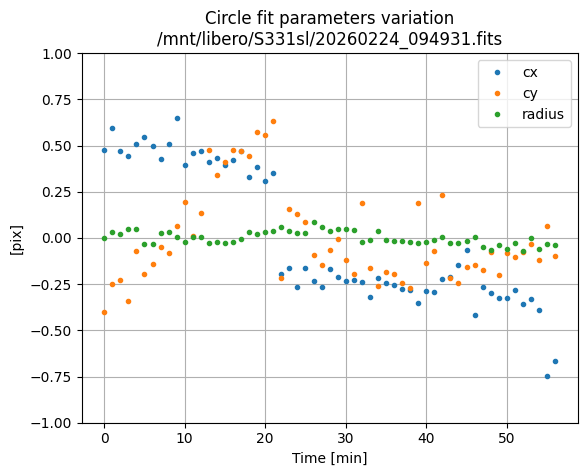

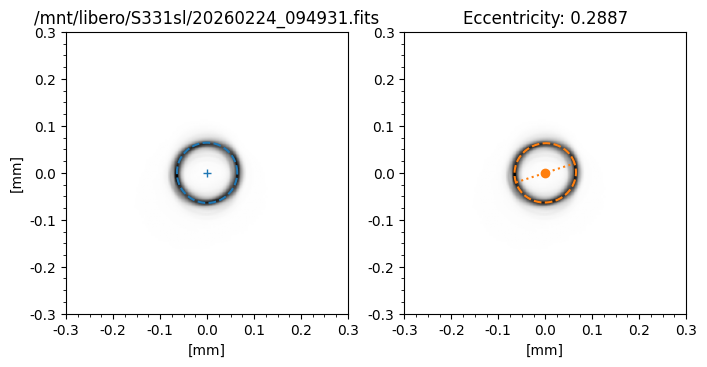

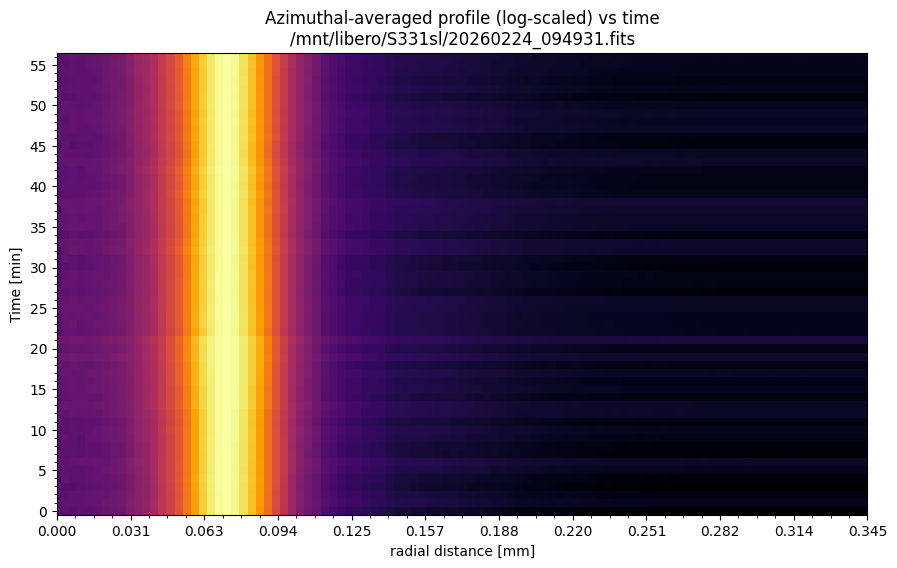

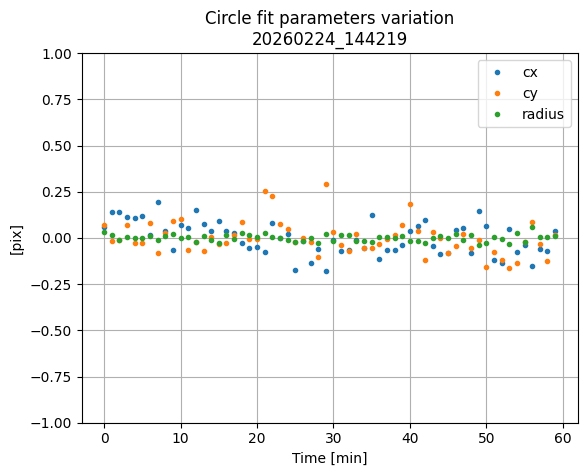

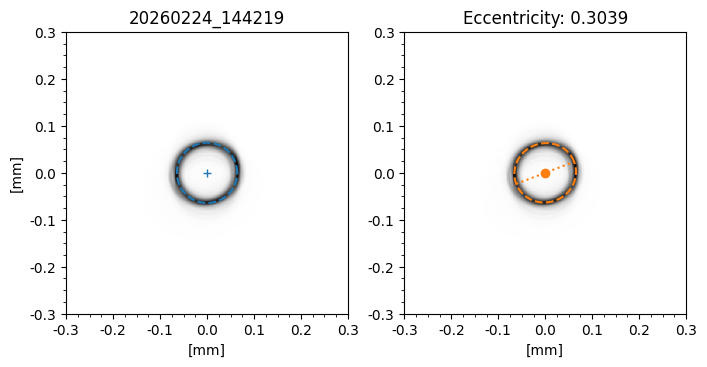

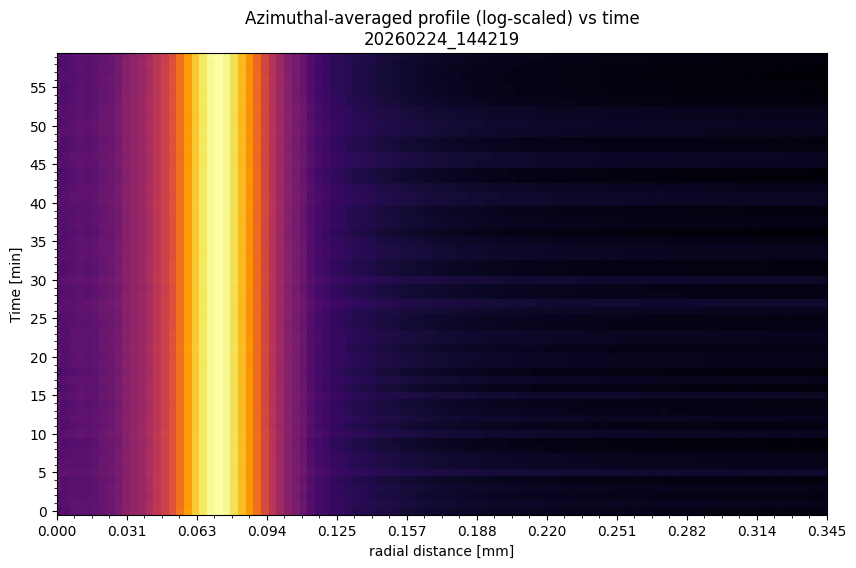

In [8]:
tnlist = ['/mnt/libero/S331sl/20260224_094931.fits',
 '/mnt/libero/S331sl/20260224_095026.fits',
 '/mnt/libero/S331sl/20260224_095121.fits',
 '/mnt/libero/S331sl/20260224_095217.fits',
 '/mnt/libero/S331sl/20260224_095312.fits',
 '/mnt/libero/S331sl/20260224_095408.fits',
 '/mnt/libero/S331sl/20260224_095503.fits',
 '/mnt/libero/S331sl/20260224_095559.fits',
 '/mnt/libero/S331sl/20260224_095654.fits',
 '/mnt/libero/S331sl/20260224_095750.fits',
 '/mnt/libero/S331sl/20260224_095845.fits',
 '/mnt/libero/S331sl/20260224_095941.fits',
 '/mnt/libero/S331sl/20260224_100036.fits',
 '/mnt/libero/S331sl/20260224_100132.fits',
 '/mnt/libero/S331sl/20260224_100227.fits',
 '/mnt/libero/S331sl/20260224_100323.fits',
 '/mnt/libero/S331sl/20260224_100418.fits',
 '/mnt/libero/S331sl/20260224_100514.fits',
 '/mnt/libero/S331sl/20260224_100609.fits',
 '/mnt/libero/S331sl/20260224_100704.fits',
 '/mnt/libero/S331sl/20260224_100800.fits',
 '/mnt/libero/S331sl/20260224_100855.fits',
 '/mnt/libero/S331sl/20260224_100951.fits',
 '/mnt/libero/S331sl/20260224_101046.fits',
 '/mnt/libero/S331sl/20260224_101142.fits',
 '/mnt/libero/S331sl/20260224_101237.fits',
 '/mnt/libero/S331sl/20260224_101333.fits',
 '/mnt/libero/S331sl/20260224_101428.fits',
 '/mnt/libero/S331sl/20260224_101524.fits',
 '/mnt/libero/S331sl/20260224_101619.fits',
 '/mnt/libero/S331sl/20260224_101715.fits',
 '/mnt/libero/S331sl/20260224_101810.fits',
 '/mnt/libero/S331sl/20260224_101905.fits',
 '/mnt/libero/S331sl/20260224_102001.fits',
 '/mnt/libero/S331sl/20260224_102056.fits',
 '/mnt/libero/S331sl/20260224_102151.fits',
 '/mnt/libero/S331sl/20260224_102247.fits',
 '/mnt/libero/S331sl/20260224_102342.fits',
 '/mnt/libero/S331sl/20260224_102438.fits',
 '/mnt/libero/S331sl/20260224_102533.fits',
 '/mnt/libero/S331sl/20260224_102628.fits',
 '/mnt/libero/S331sl/20260224_102724.fits',
 '/mnt/libero/S331sl/20260224_102819.fits',
 '/mnt/libero/S331sl/20260224_102915.fits',
 '/mnt/libero/S331sl/20260224_103010.fits',
 '/mnt/libero/S331sl/20260224_103106.fits',
 '/mnt/libero/S331sl/20260224_103201.fits',
 '/mnt/libero/S331sl/20260224_103257.fits',
 '/mnt/libero/S331sl/20260224_103352.fits',
 '/mnt/libero/S331sl/20260224_103448.fits',
 '/mnt/libero/S331sl/20260224_103543.fits',
 '/mnt/libero/S331sl/20260224_103638.fits',
 '/mnt/libero/S331sl/20260224_103734.fits',
 '/mnt/libero/S331sl/20260224_103829.fits',
 '/mnt/libero/S331sl/20260224_103925.fits',
 '/mnt/libero/S331sl/20260224_104243.fits',
 '/mnt/libero/S331sl/20260224_104338.fits']
tnlist2=['20260224_144219',
 '20260224_144320',
 '20260224_144420',
 '20260224_144521',
 '20260224_144622',
 '20260224_144722',
 '20260224_144823',
 '20260224_144923',
 '20260224_145024',
 '20260224_145124',
 '20260224_145225',
 '20260224_145325',
 '20260224_145426',
 '20260224_145526',
 '20260224_145627',
 '20260224_145727',
 '20260224_145828',
 '20260224_145928',
 '20260224_150029',
 '20260224_150130',
 '20260224_150230',
 '20260224_150331',
 '20260224_150431',
 '20260224_150532',
 '20260224_150632',
 '20260224_150733',
 '20260224_150834',
 '20260224_150934',
 '20260224_151034',
 '20260224_151135',
 '20260224_151235',
 '20260224_151336',
 '20260224_151437',
 '20260224_151537',
 '20260224_151638',
 '20260224_151738',
 '20260224_151839',
 '20260224_151939',
 '20260224_152040',
 '20260224_152140',
 '20260224_152241',
 '20260224_152341',
 '20260224_152442',
 '20260224_152543',
 '20260224_152643',
 '20260224_152744',
 '20260224_152844',
 '20260224_152945',
 '20260224_153046',
 '20260224_153146',
 '20260224_153247',
 '20260224_153347',
 '20260224_153448',
 '20260224_153548',
 '20260224_153648',
 '20260224_153749',
 '20260224_153849',
 '20260224_153950',
 '20260224_154051',
 '20260224_154151']

_=analyse_tns(tnlist)
_=analyse_tns(tnlist2)

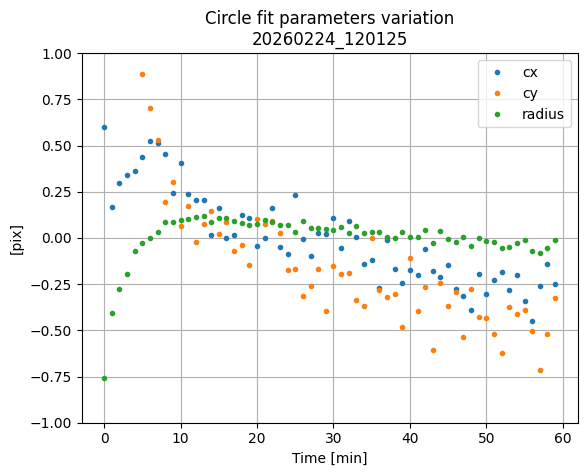

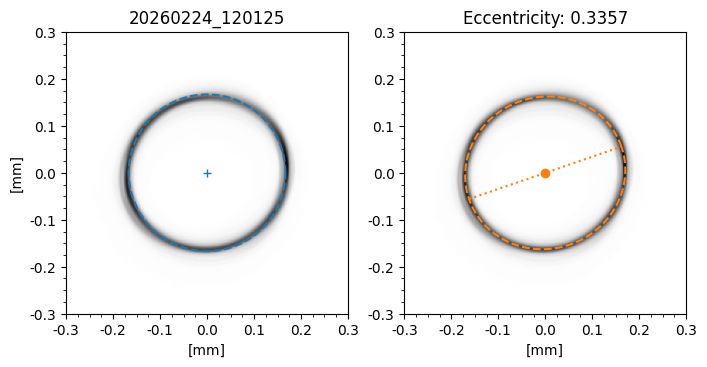

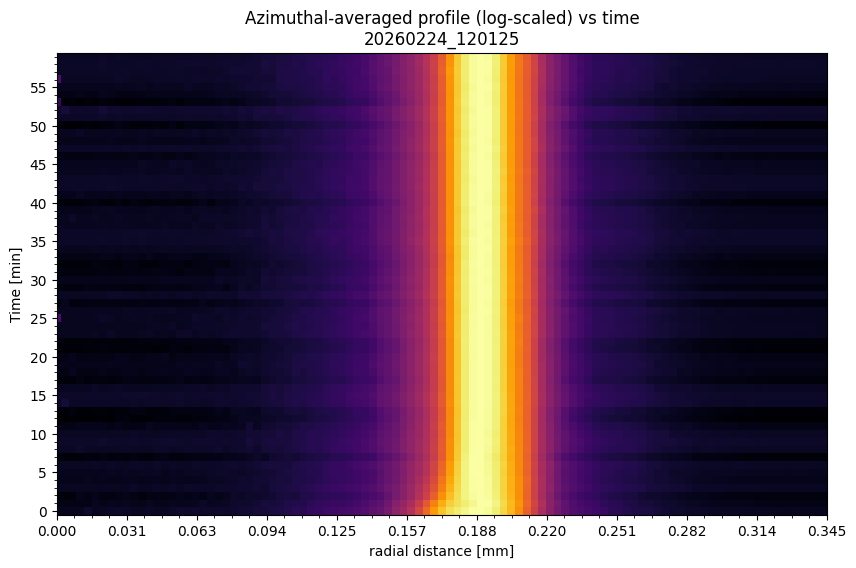

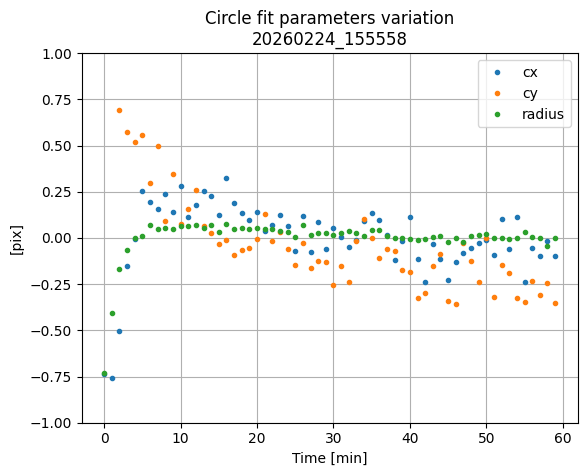

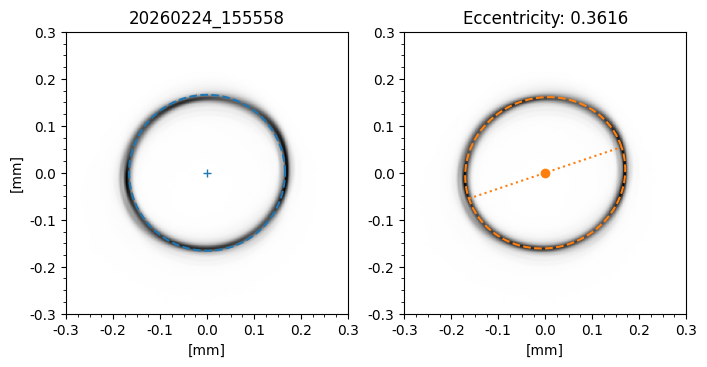

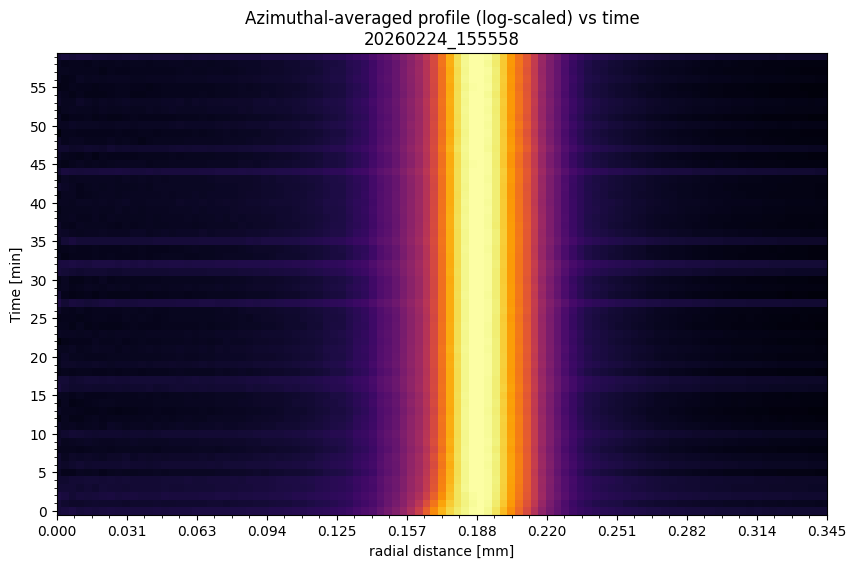

In [9]:
tnlist = ['20260224_120125',
 '20260224_120226',
 '20260224_120326',
 '20260224_120427',
 '20260224_120527',
 '20260224_120628',
 '20260224_120728',
 '20260224_120829',
 '20260224_120929',
 '20260224_121030',
 '20260224_121130',
 '20260224_121231',
 '20260224_121331',
 '20260224_121432',
 '20260224_121532',
 '20260224_121633',
 '20260224_121733',
 '20260224_121834',
 '20260224_121934',
 '20260224_122035',
 '20260224_122135',
 '20260224_122235',
 '20260224_122336',
 '20260224_122436',
 '20260224_122537',
 '20260224_122637',
 '20260224_122738',
 '20260224_122838',
 '20260224_122938',
 '20260224_123039',
 '20260224_123139',
 '20260224_123240',
 '20260224_123341',
 '20260224_123441',
 '20260224_123542',
 '20260224_123642',
 '20260224_123743',
 '20260224_123843',
 '20260224_123944',
 '20260224_124044',
 '20260224_124145',
 '20260224_124245',
 '20260224_124346',
 '20260224_124446',
 '20260224_124547',
 '20260224_124647',
 '20260224_124747',
 '20260224_124848',
 '20260224_124948',
 '20260224_125049',
 '20260224_125149',
 '20260224_125248',
 '20260224_125348',
 '20260224_125449',
 '20260224_125550',
 '20260224_125650',
 '20260224_125751',
 '20260224_125851',
 '20260224_125951',
 '20260224_130052']
tnlist2 = ['20260224_155558',
 '20260224_155658',
 '20260224_155759',
 '20260224_155859',
 '20260224_160000',
 '20260224_160100',
 '20260224_160201',
 '20260224_160301',
 '20260224_160402',
 '20260224_160502',
 '20260224_160603',
 '20260224_160703',
 '20260224_160804',
 '20260224_160904',
 '20260224_161005',
 '20260224_161105',
 '20260224_161206',
 '20260224_161306',
 '20260224_161407',
 '20260224_161508',
 '20260224_161608',
 '20260224_161709',
 '20260224_161809',
 '20260224_161909',
 '20260224_162010',
 '20260224_162111',
 '20260224_162211',
 '20260224_162312',
 '20260224_162412',
 '20260224_162513',
 '20260224_162613',
 '20260224_162714',
 '20260224_162814',
 '20260224_162915',
 '20260224_163015',
 '20260224_163116',
 '20260224_163216',
 '20260224_163317',
 '20260224_163417',
 '20260224_163518',
 '20260224_163618',
 '20260224_163719',
 '20260224_163819',
 '20260224_163920',
 '20260224_164020',
 '20260224_164121',
 '20260224_164221',
 '20260224_164322',
 '20260224_164422',
 '20260224_164523',
 '20260224_164623',
 '20260224_164723',
 '20260224_164824',
 '20260224_164925',
 '20260224_165025',
 '20260224_165125',
 '20260224_165226',
 '20260224_165327',
 '20260224_165427',
 '20260224_165528']

_=analyse_tns(tnlist)
_=analyse_tns(tnlist2)


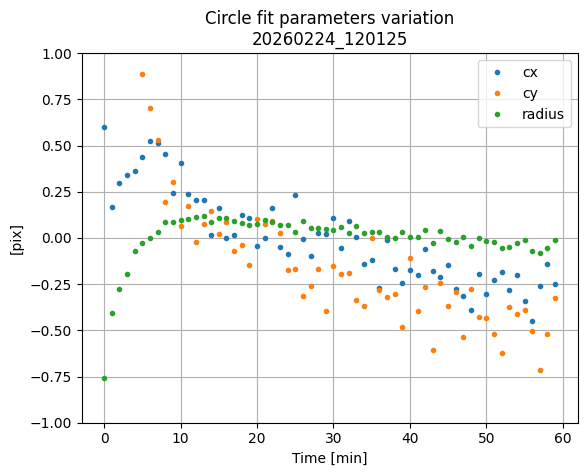

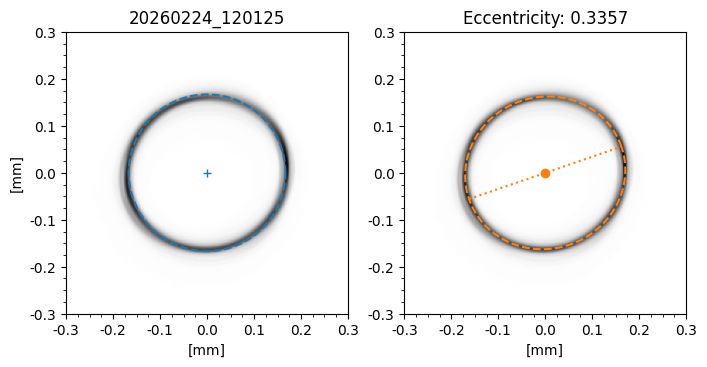

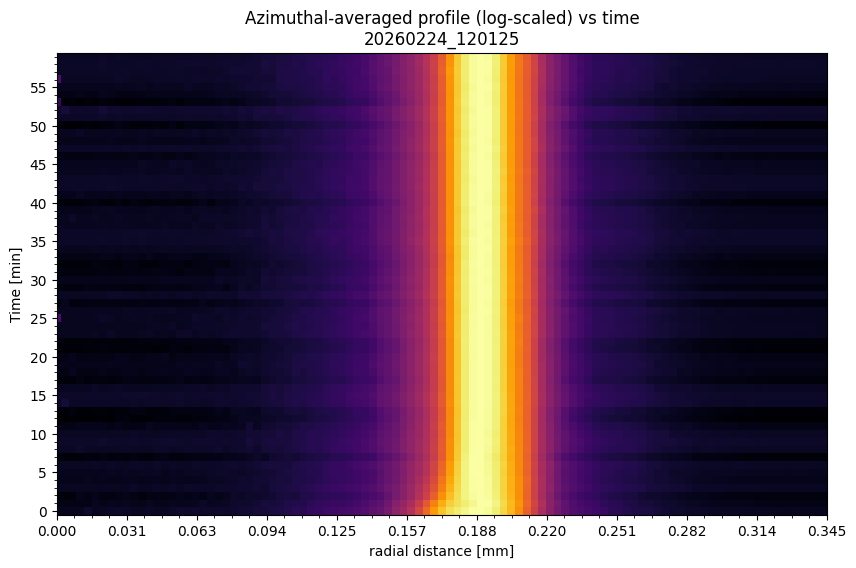

In [10]:
tnlist3kHzCL=['20260302_130215',
'20260302_130321',
'20260302_130426',
'20260302_130531',
'20260302_130636',
'20260302_130742',
'20260302_130847',
'20260302_130953',
'20260302_131059',
'20260302_131204',
'20260302_131309',
'20260302_131414',
'20260302_131520',
'20260302_131625',
'20260302_131730',
'20260302_131835',
'20260302_131942',
'20260302_132048',
'20260302_132153',
'20260302_132300',
'20260302_132405',
'20260302_132511',
'20260302_132616',
'20260302_132721',
'20260302_132826',
'20260302_132932',
'20260302_133037',
'20260302_133142',
'20260302_133246',
'20260302_133353',
'20260302_133457',
'20260302_133604',
'20260302_133710',
'20260302_133816',
'20260302_133921',
'20260302_134027',
'20260302_134132',
'20260302_134237',
'20260302_134344',
'20260302_134449',
'20260302_134555',
'20260302_134700',
'20260302_134805',
'20260302_134910',
'20260302_135015',
'20260302_135120',
'20260302_135225',
'20260302_135331',
'20260302_135437',
'20260302_135544',
'20260302_135651',
'20260302_135756',
'20260302_135903',
'20260302_140008',
'20260302_140114',
'20260302_140222',
'20260302_140327',
'20260302_140432',
'20260302_140538',
'20260302_140642']

_=analyse_tns(tnlist)

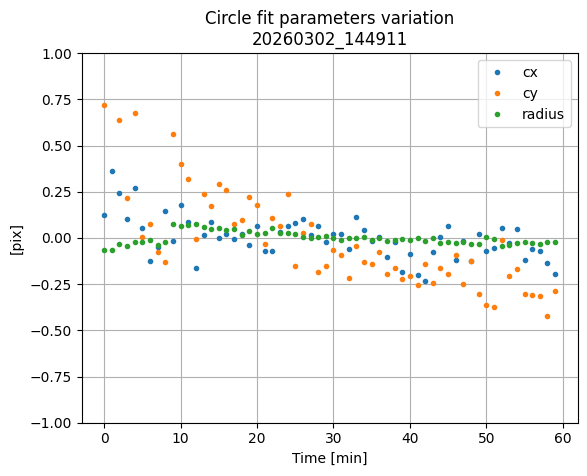

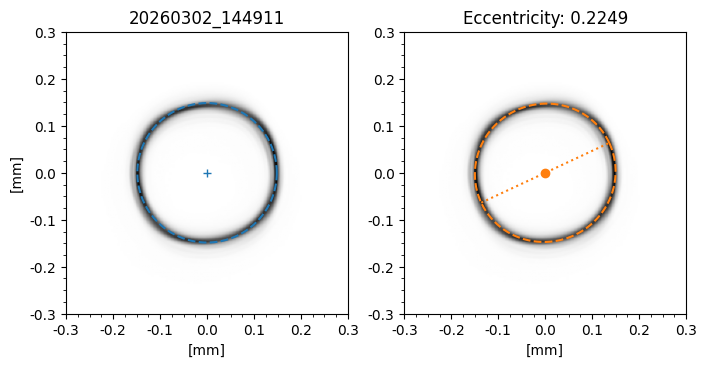

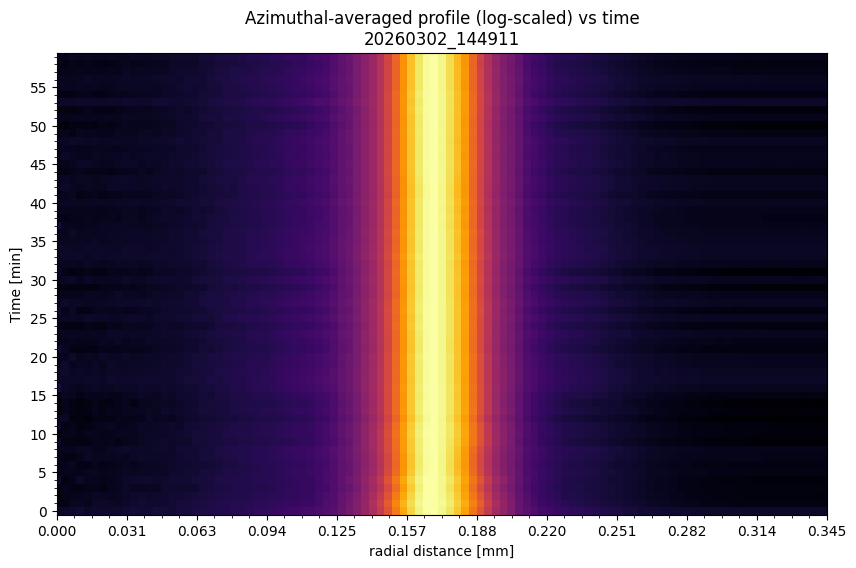

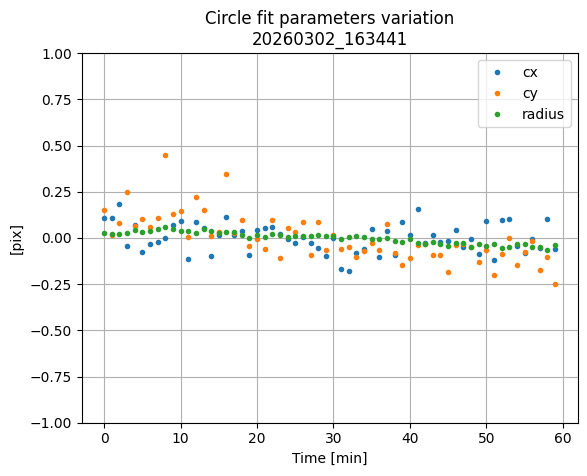

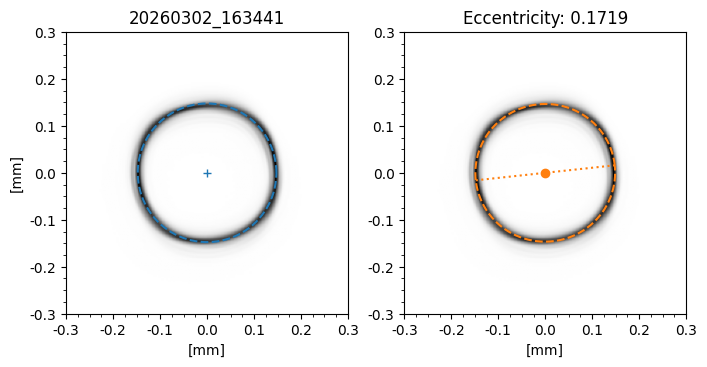

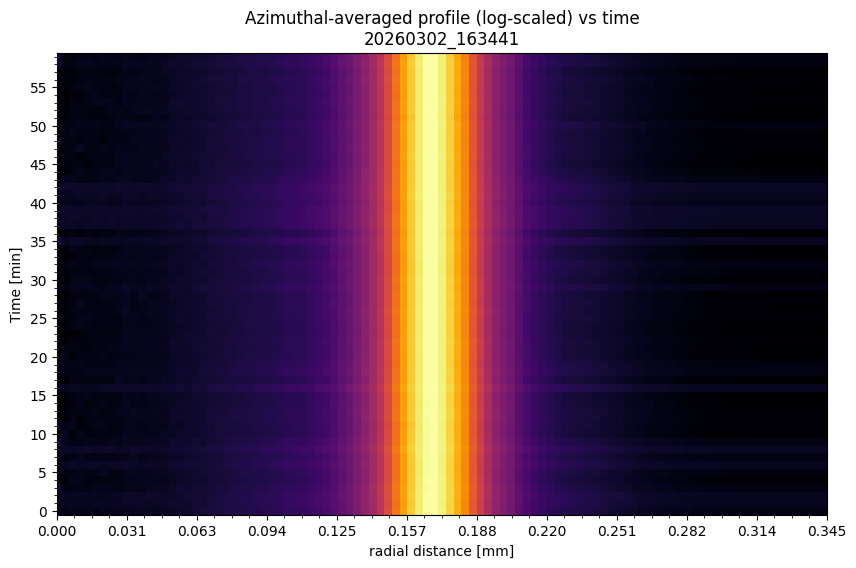

In [11]:
tnlist3kHzOL = ['20260302_144911',
               '20260302_145015',
               '20260302_145121',
               '20260302_145228',
               '20260302_145336',
               '20260302_145441',
               '20260302_145546',
               '20260302_145652',
               '20260302_145757',
               '20260302_145902',
               '20260302_150006',
               '20260302_150112',
               '20260302_150217',
               '20260302_150322',
               '20260302_150427',
               '20260302_150532',
               '20260302_150637',
               '20260302_150742',
               '20260302_150847',
               '20260302_150952',
               '20260302_151057',
               '20260302_151202',
               '20260302_151308',
               '20260302_151413',
               '20260302_151519',
               '20260302_151625',
               '20260302_151730',
               '20260302_151835',
               '20260302_151940',
               '20260302_152045',
               '20260302_152150',
               '20260302_152256',
               '20260302_152403',
               '20260302_152508',
               '20260302_152613',
               '20260302_152720',
               '20260302_152826',
               '20260302_152932',
               '20260302_153039',
               '20260302_153143',
               '20260302_153248',
               '20260302_153353',
               '20260302_153458',
               '20260302_153603',
               '20260302_153708',
               '20260302_153813',
               '20260302_153918',
               '20260302_154023',
               '20260302_154127',
               '20260302_154233',
               '20260302_154338',
               '20260302_154445',
               '20260302_154550',
               '20260302_154655',
               '20260302_154800',
               '20260302_154905',
               '20260302_155011',
               '20260302_155116',
               '20260302_155221',
               '20260302_155326']

tnlist3kHzOL2 = ['20260302_163441',
                '20260302_163546',
                '20260302_163651',
                '20260302_163757',
                '20260302_163902',
                '20260302_164007',
                '20260302_164114',
                '20260302_164219',
                '20260302_164325',
                '20260302_164430',
                '20260302_164535',
                '20260302_164640',
                '20260302_164746',
                '20260302_164853',
                '20260302_164958',
                '20260302_165104',
                '20260302_165209',
                '20260302_165313',
                '20260302_165419',
                '20260302_165523',
                '20260302_165631',
                '20260302_165737',
                '20260302_165842',
                '20260302_165947',
                '20260302_170052',
                '20260302_170158',
                '20260302_170304',
                '20260302_170409',
                '20260302_170514',
                '20260302_170619',
                '20260302_170725',
                '20260302_170830',
                '20260302_170936',
                '20260302_171041',
                '20260302_171146',
                '20260302_171252',
                '20260302_171357',
                '20260302_171503',
                '20260302_171608',
                '20260302_171713',
                '20260302_171818',
                '20260302_171923',
                '20260302_172030',
                '20260302_172134',
                '20260302_172239',
                '20260302_172344',
                '20260302_172450',
                '20260302_172554',
                '20260302_172700',
                '20260302_172805',
                '20260302_172911',
                '20260302_173017',
                '20260302_173122',
                '20260302_173228',
                '20260302_173333',
                '20260302_173438',
                '20260302_173543',
                '20260302_173649','20260302_173754',
'20260302_173859']

_= analyse_tns(tn_list=tnlist3kHzOL)
_= analyse_tns(tn_list=tnlist3kHzOL2)

In [ ]:
def plot_deconvolution(psf_tn:str, circle_tn:str, title:str='', thr:float=0.0):
    img = read_tn_data(psf_tn)
    cx, cy = peak_xy_subpixel(img)
    cimg = read_tn_data(circle_tn)
    ecx,ecy,radius = best_circle_fit(cimg, show_fit=False)

    ext = 2.2*radius
    xlim = [int(cx-ext),int(cx+ext)]
    ylim = [int(cy-ext),int(cy+ext)]

    dx = xlim[1] - xlim[0]
    dy = ylim[1] - ylim[0]

    cxlim = [int(ecx-dx/2), int(ecx+dx/2)]
    cylim = [int(ecy-dy/2), int(ecy+dy/2)]

    psf = img[ylim[0]:ylim[1], xlim[0]:xlim[1]]
    circle = cimg[cylim[0]:cylim[1], cxlim[0]:cxlim[1]]

    psf *= circle.max()/psf.max()
    circle *= circle > thr*circle.max()

    psf_fft = np.fft.fft2(psf)
    circle_fft = np.fft.fft2(circle)

    deconv = np.fft.ifft2(circle_fft / psf_fft)
    deconv = np.fft.ifftshift(deconv)
    deconv2 = np.abs(deconv * np.conj(deconv))

    plt.figure(figsize=(16,4))
    plt.subplot(1,3,1)
    plt.imshow(psf, origin='lower', cmap='gray_r')
    plt.colorbar()
    plt.title('PSF\n'+psf_tn)
    plt.subplot(1,3,2)
    plt.imshow(circle, origin='lower', cmap='gray_r')
    plt.colorbar()
    plt.title('Modulation circle\n'+circle_tn)
    plt.subplot(1,3,3)
    plt.imshow(deconv2, origin='lower', cmap='RdBu')
    plt.colorbar()
    plt.title('Deconvolution\n'+title)

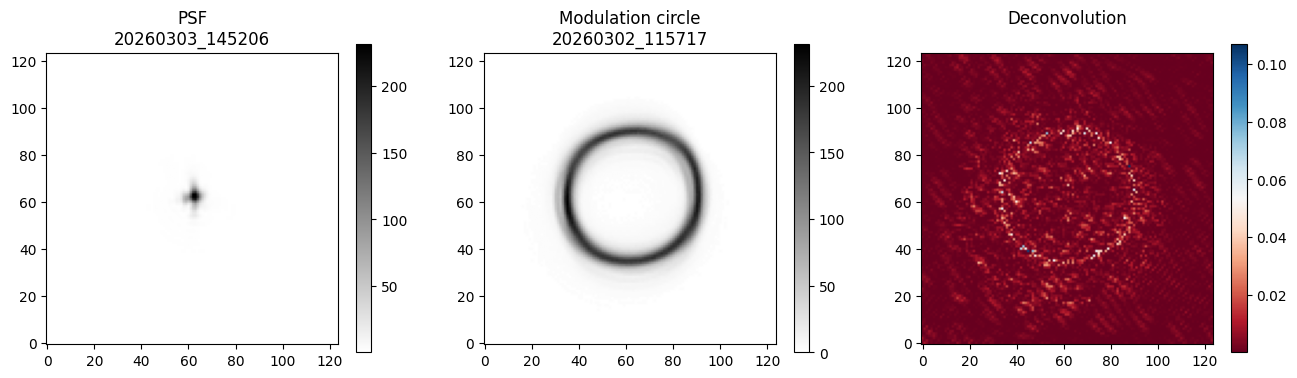

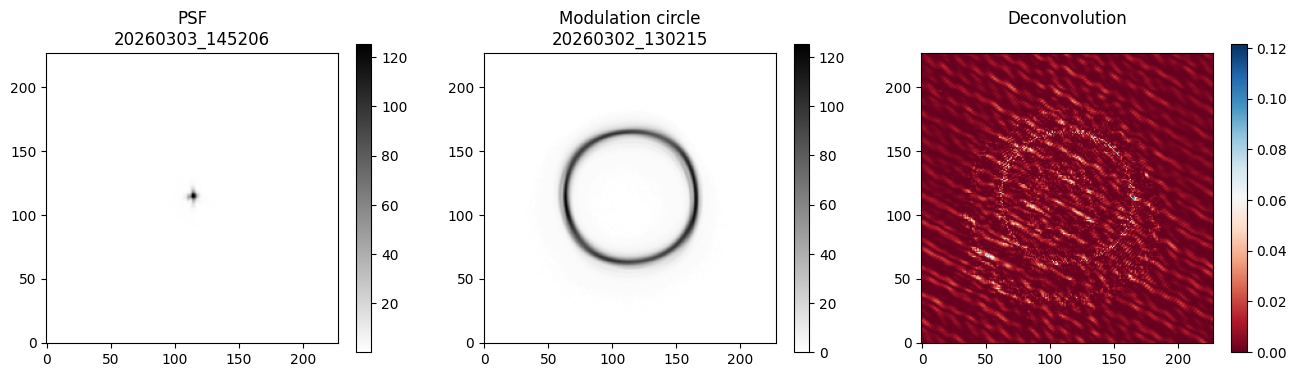

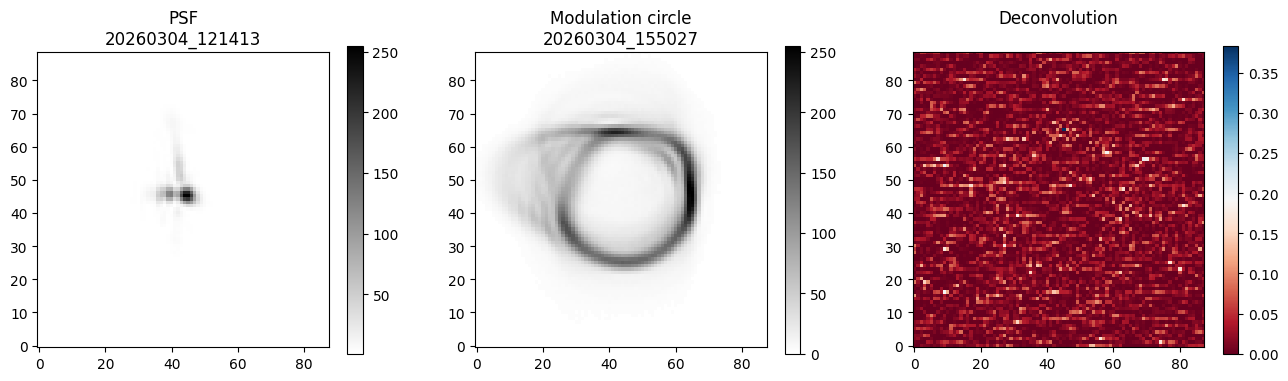

In [75]:
plot_deconvolution(psf_tn='20260303_145206', circle_tn='20260302_115717')
plot_deconvolution(psf_tn='20260303_145206', circle_tn='20260302_130215')
plot_deconvolution(psf_tn='20260304_121413', circle_tn='20260304_155027')#, title='1 kHz, 1.5 Vpp')

In [12]:
# # 2 kHz
# _= analyse_tns(['20260302_113200']) # closed loop
# _= analyse_tns(['20260302_111313']) # open loop

# # 3 kHz
# _= analyse_tns(['20260302_123058']) # closed loop '20260302_114559'
# _= analyse_tns(['20260302_115717']) # open loop

# # 4 kHz
# _= analyse_tns(['20260302_122004']) # closed loop
# _= analyse_tns(['20260302_120755']) # open loop

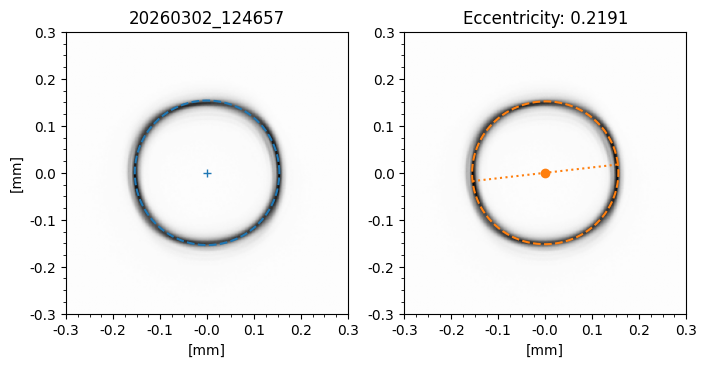

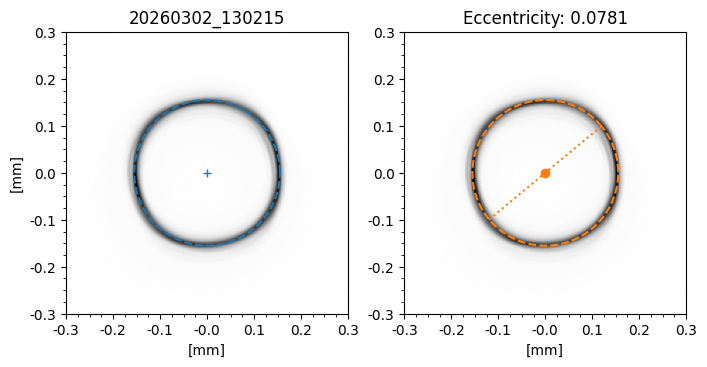

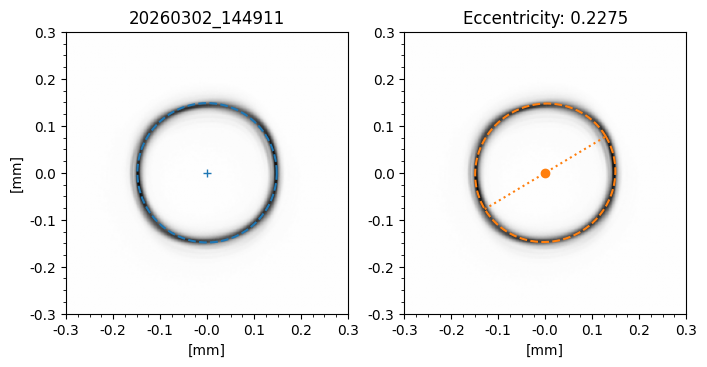

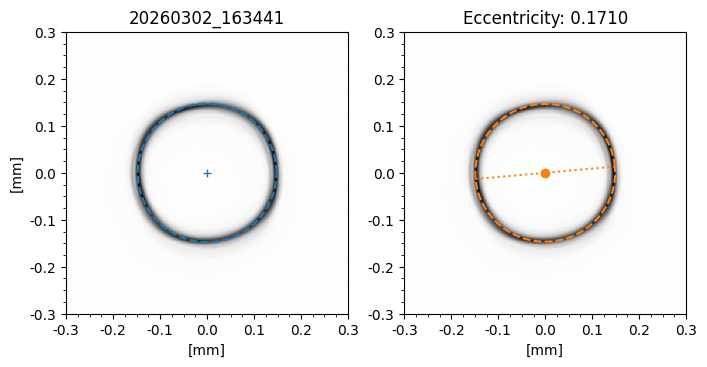

In [13]:
# _= analyse_tns(['20260302_123312'])
# _= analyse_tns(['20260302_123603'])
# _= analyse_tns(['20260302_123704'])
# _= analyse_tns(['20260302_123804'])


_= analyse_tns(['20260302_124657'])
_= analyse_tns(['20260302_130215'])

_= analyse_tns(['20260302_144911'])
_= analyse_tns(['20260302_163441'])

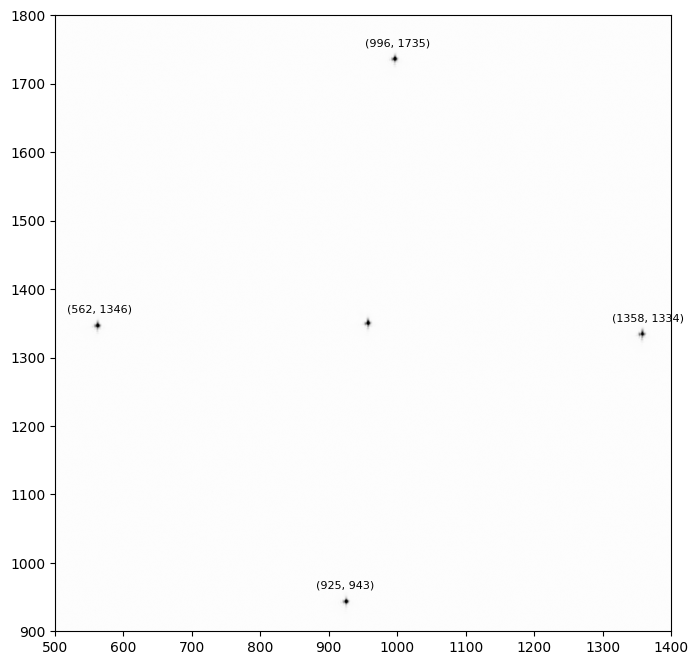

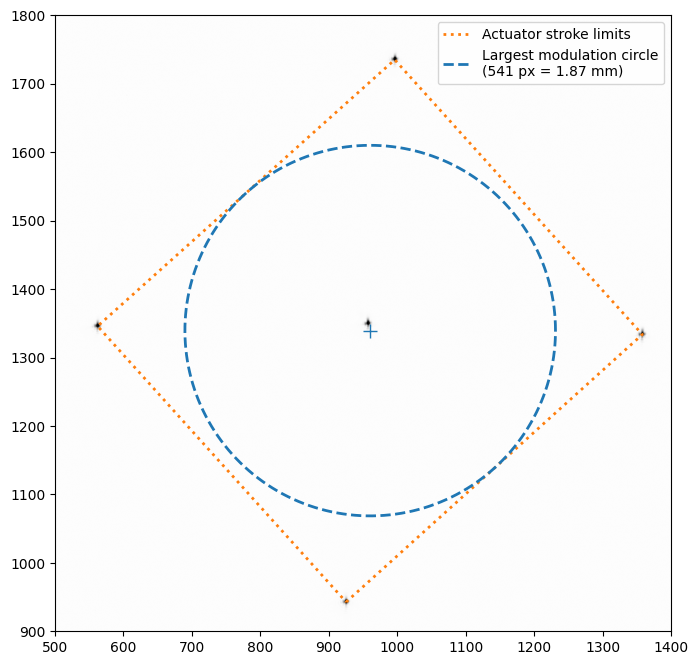

Vertices (x, y):
  v1: (925.39, 942.78)
  v2: (1358.16, 1333.63)
  v3: (562.28, 1345.76)
  v4: (996.38, 1735.05)
Rectangle center: (960.55, 1339.30)
Inscribed circle radius: 270.71 px


In [ ]:
tnlist = ['20260302_091922', '20260302_092057', '20260302_092338', '20260302_092215','20260302_091800']
img = get_img_from_tns(tnlist)

img_stack = np.stack([read_tn_data(tn) for tn in tnlist[:-1]])
vertices = np.array([peak_xy_subpixel(im) for im in img_stack], dtype=np.float64)

plt.figure(figsize=(8, 8))
plt.imshow(img, origin='lower', cmap='gray_r')
plt.ylim([900,1800])
plt.xlim([500,1400])

for i, (x, y) in enumerate(vertices):
    plt.text(x-44, y+20, f'({x:1.0f}, {y:1.0f})', fontsize=8)

vertices = vertices[:4,:]

center = np.mean(vertices, axis=0)
angles = np.arctan2(vertices[:, 1] - center[1], vertices[:, 0] - center[0])
order = np.argsort(angles)
rect = vertices[order]

edges = np.linalg.norm(np.roll(rect, -1, axis=0) - rect, axis=1)
width = 0.5 * (edges[0] + edges[2])
height = 0.5 * (edges[1] + edges[3])
r_in = 0.5 * min(width, height)

plt.figure(figsize=(8, 8))
plt.imshow(img, origin='lower', cmap='gray_r')

# draw vertices and rectangle
rect_closed = np.vstack([rect, rect[0]])
plt.plot(rect_closed[:, 0], rect_closed[:, 1], ':', c='C1', lw=2, label='Actuator stroke limits')

# draw inscribed circle centered on rectangle center
th = np.linspace(0, 2 * np.pi, 400)
xc = center[0] + r_in * np.cos(th)
yc = center[1] + r_in * np.sin(th)
plt.plot(xc, yc, '--', c='C0', lw=2, label=f'Largest modulation circle\n({2*r_in:.0f} px = {2*r_in*3.45/1000:.2f} mm)')
plt.plot(center[0], center[1], '+', c='C0', ms=10)

plt.legend(loc='best')
plt.xlim([500, 1400])
plt.ylim([900, 1800])
plt.show()

print('Vertices (x, y):')
for i, (xv, yv) in enumerate(vertices, 1):
    print(f'  v{i}: ({xv:.2f}, {yv:.2f})')
print(f'Rectangle center: ({center[0]:.2f}, {center[1]:.2f})')
print(f'Inscribed circle radius: {r_in:.2f} px')

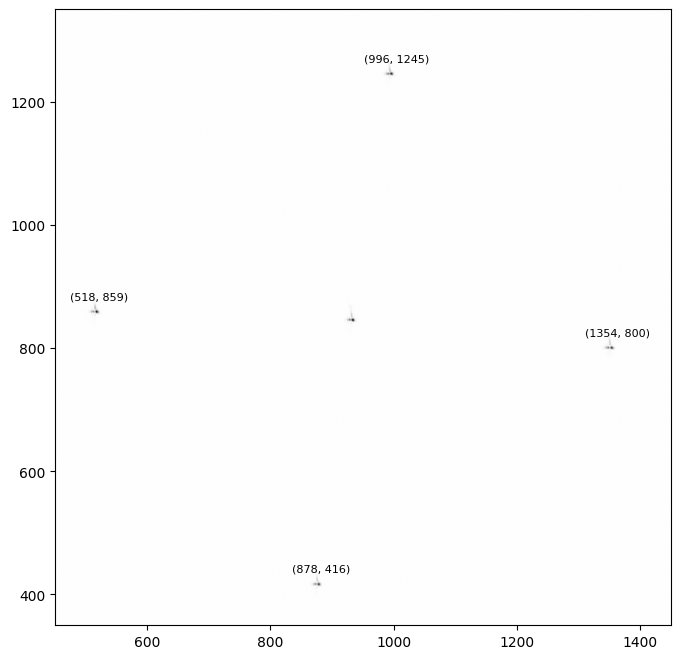

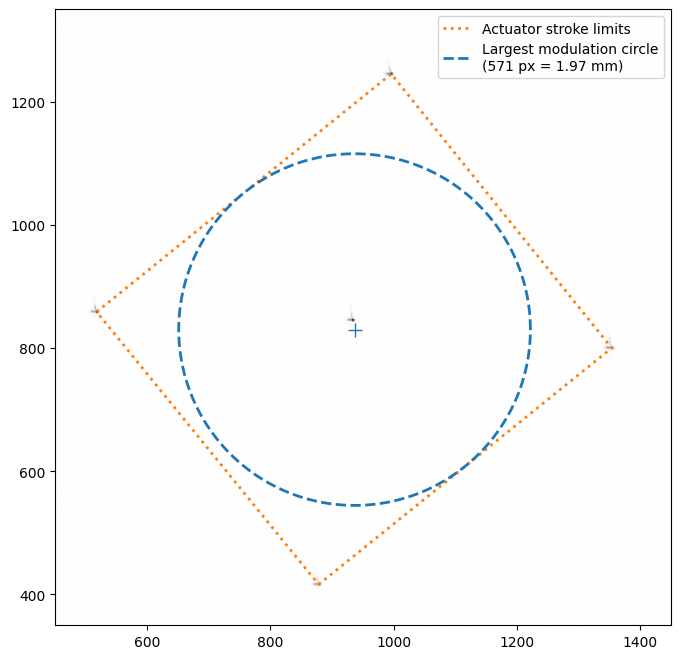

Vertices (x, y):
  v1: (878.23, 416.25)
  v2: (1353.97, 800.08)
  v3: (517.93, 858.74)
  v4: (996.05, 1245.09)
Rectangle center: (936.55, 830.04)
Inscribed circle radius: 285.43 px


In [ ]:
tnlist = ['20260304_121703','20260304_121802','20260304_122029','20260304_121915','20260304_121603']
img = get_img_from_tns(tnlist) # S330

img_stack = np.stack([read_tn_data(tn) for tn in tnlist[:-1]])
vertices = np.array([peak_xy_subpixel(im) for im in img_stack], dtype=np.float64)

plt.figure(figsize=(8, 8))
plt.imshow(img, origin='lower', cmap='gray_r')
plt.ylim([350,1350])
plt.xlim([450,1450])
for i, (x, y) in enumerate(vertices):
    plt.text(x-44, y+20, f'({x:1.0f}, {y:1.0f})', fontsize=8)

vertices = vertices[:4,:].copy()
center = np.mean(vertices, axis=0)
angles = np.arctan2(vertices[:, 1] - center[1], vertices[:, 0] - center[0])
order = np.argsort(angles)
rect = vertices[order]

edges = np.linalg.norm(np.roll(rect, -1, axis=0) - rect, axis=1)
width = 0.5 * (edges[0] + edges[2])
height = 0.5 * (edges[1] + edges[3])
r_in = 0.5 * min(width, height)

plt.figure(figsize=(8, 8))
plt.imshow(img, origin='lower', cmap='gray_r')

# draw vertices and rectangle
rect_closed = np.vstack([rect, rect[0]])
plt.plot(rect_closed[:, 0], rect_closed[:, 1], ':', c='C1', lw=2, label='Actuator stroke limits')

# draw inscribed circle centered on rectangle center
th = np.linspace(0, 2 * np.pi, 400)
xc = center[0] + r_in * np.cos(th)
yc = center[1] + r_in * np.sin(th)
plt.plot(xc, yc, '--', c='C0', lw=2, label=f'Largest modulation circle\n({2*r_in:.0f} px = {2*r_in*3.45/1000:.2f} mm)')
plt.plot(center[0], center[1], '+', c='C0', ms=10)

plt.legend(loc='best')
plt.ylim([350,1350])
plt.xlim([450,1450])
plt.show()

print('Vertices (x, y):')
for i, (xv, yv) in enumerate(vertices, 1):
    print(f'  v{i}: ({xv:.2f}, {yv:.2f})')
print(f'Rectangle center: ({center[0]:.2f}, {center[1]:.2f})')
print(f'Inscribed circle radius: {r_in:.2f} px')